# Práctica 4: Multiperceptrón

## Parte 1 - Multiperceptrón con SciKit-Learn

### Ejercicio 1

Se entrenó una red neuronal multiperceptrón para resolver un problema de clasificación y al medir su desempeño sobre el conjunto de datos de entrenamiento se obtuvo la siguiente matriz de confusión: 

| 17 | 0 | 1 | 0 | 1 |
|----|---|---|---|---|
| 0 | 12 | 0 | 0 | 0 |
| 0 | 0 | 12 | 0 | 0 |
| 2 | 0 | 0 | 38 | 0 |
| 0 | 8 | 0 | 0 | 61 |

1. En base a esta información, indique:
   - Cuántos ejemplos se utilizaron en el entrenamiento.
  
Se usaron $152$ ejemplos en el entrenamiento: $152 = 17 + 1 + 1 + 12 + 12 + 2 + 38 + 8 + 61$.

   - Cuántas clases puede reconocer este multiperceptrón.

Puede reconocer 5 clases (número de columnas de la matriz).

   - Cuál es la precisión (**accuracy**) de la red sobre el conjunto de ejemplos completo.

El **accuracy** se calcula como los ejemplos predecidos correctamente / los ejemplos totales: $\frac{140}{152} = 92.10\%$

   - Cuáles son los valores de precisión de la red al responder por cada uno de los valores de clase (**precision**).

La **precisión** a nivel de clase se calcula como los ejemplos predecidos correctamente / los ejemplos predecidos para la clase:
- Clase 1: $\frac{17}{19} = 89.47\%$
- Clase 2: $\frac{12}{20} = 60\%$
- Clase 3: $\frac{12}{13} = 92.31\%$
- Clase 4: $\frac{38}{38} = 100\%$
- Clase 5: $\frac{61}{62} = 98.39\%$

   - Cuáles son los valores de sensibilidad de la red al responder por cada uno de los valores de clase (**recall**).

Lo mismo que antes pero a nivel de fila:
- Clase 1: $\frac{17}{19} = 89.47\%$
- Clase 2: $\frac{12}{12} = 100\%$
- Clase 3: $\frac{12}{12} = 100\%$
- Clase 4: $\frac{38}{40} = 95\%$
- Clase 5: $\frac{61}{69} = 88.40\%$

2. Identifique la clase con el mejor valor de F1-score.

El F1-score se calcula como $2 \cdot \frac{precision\ \cdot\ recall}{precision\ +\ recall}$
- Clase 1: $2 \cdot \frac{0.8947 \cdot 0.8947}{0.8947 + 0.8947} = 0.8947$
- Clase 2: $2 \cdot \frac{0.6 \cdot 1}{0.6 + 1} = 0.75$
- Clase 3: $2 \cdot \frac{0.9231 \cdot 1}{0.9231 + 1} = 0.96$
- Clase 4: $2 \cdot \frac{1 \cdot 0.95}{1 + 0.95} = 0.9743$
- Clase 5: $2 \cdot \frac{0.9839 \cdot 0.8840}{0.9839 + 0.8840} = 0.9312$

La clase con mayor F1-score es la **CLase 4**.

### Ejercicio 2

Se desea utilizar una red multiperceptrón para reconocer muestras de tres variedades diferentes de trigo: Kama, Rosa y Canadiense. Para entrenarla se utilizará una parte de los ejemplos del archivo **SEMILLAS.CSV**.

Fuente de datos: **Seeds Data Set** - [https://archive.ics.uci.edu/ml/datasets/seeds](https://archive.ics.uci.edu/ml/datasets/seeds)

1. Con respecto a la arquitectura, indique:
   - La cantidad de neuronas de la capa de entrada.
  
La cantidad de neuronas de la capa de entrada serían 8 (todas las columnas menos la que queremos predecir + 1 por el bias)

   - La cantidad de neuronas de la capa de salida.

La cantidad de neuronas de la capa de salida serían 3, una por cada tipo de trigo.

   - La cantidad de pesos (arcos) que tiene la red si se utiliza una única capa oculta formada por 4 neuronas.

La cantidad de arcos de la red se calcularía como: $(8 \cdot 4) + (4 \cdot 3) = 44$

2. La arquitectura del multiperceptrón utilizado para predecir los 3 tipos de semillas está formada por 3 capas: la capa de entrada, una única capa oculta de 4 neuronas y la capa de salida. Las funciones de activación para las capas oculta y de salida son “tanh” y “sigmoid” respectivamente. Indique cuáles de los siguientes factores inciden en la dirección de cambio (signo de la modificación) de los pesos de la red:
   - El error cometido en la predicción.
   - El valor de la derivada de la función de activación.
   - Los valores anteriores de los pesos de la red.

Los factores que inciden en la dirección de cambio de los pesos de la red serían El error cometido en la predicción y Los valores anteriores de los pesos de la red.

3. Luego de ingresar una muestra de semilla a la red se obtiene como salida (0.78, 0, 0). Utilizando la arquitectura descripta en b), indique cuántos pesos de la red serán modificados sabiendo que la respuesta esperada es (1, 0, 0).

La cantidad de pesos que se tienen que modificar serían 4 que son los que le llegan a la neurona de la capa de salida que predice Tipo1, y luego todos los que conectan la capa de entrada con la capa oculta, es decir, $(8 \cdot 4) + 4 = 36$.

In [1]:
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

df_semillas = pd.read_csv("../Datos/semillas.csv")

df_semillas.head(5)

,Area,Perimetro,Compacidad,LongNucleo,AnchoNucleo,Asimetria,LongSurco,Clase
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,Tipo1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,Tipo1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,Tipo1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,Tipo1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,Tipo1


### Ejercicio 3

El archivo **Vinos.csv** tiene información referida a 13 características químicas y/o visuales de varias muestras de vinos pertenecientes a 3 clases distintas.

Utilice el 80% de los ejemplos del archivo Vinos.csv para entrenar un multiperceptrón que sea capaz que distinguir entre las 3 clases de vinos. Observe la tasa de acierto obtenida sobre el 20% restante.

Fuente de datos: **Wine Data Set** - [https://archive.ics.uci.edu/ml/datasets/wine](https://archive.ics.uci.edu/ml/datasets/wine)

In [2]:
def visualizar_en_2d(X_scaled, y):
    tsne = TSNE(n_components=2, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)
    y_cat = y.astype("category")

    plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_cat.cat.codes, cmap='viridis')
    plt.title("Distribución de las clases en 2D usando t-SNE")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.show()

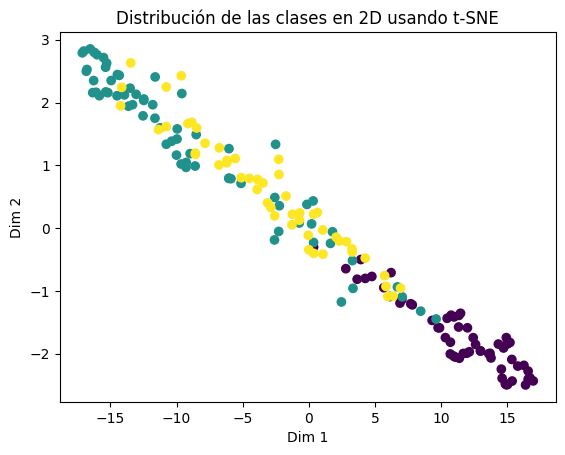

y_pred: [[0 0 1]
 [1 0 0]
 [0 0 1]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [0 1 0]
 [1 0 0]
 [0 0 1]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [0 1 0]
 [1 0 0]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [1 0 0]
 [0 1 0]
 [1 0 0]
 [0 0 1]
 [1 0 0]
 [0 1 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]]
acc_score: 0.9166666666666666


In [3]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score

df_vinos = pd.read_csv("../Datos/Vinos.csv", delimiter=";")

X = np.array(df_vinos.iloc[:,1:])
y = df_vinos.iloc[:,0]

visualizar_en_2d(X, y)

label_binarizer = LabelBinarizer()
y = label_binarizer.fit_transform(y)

standard_scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)

alpha = 0.1
error = 1.0e-4
iteraciones = 5000

model = MLPClassifier(
    max_iter=iteraciones,
    hidden_layer_sizes=(2),
    alpha=alpha,
    solver="adam",
    activation="tanh",
    tol=error,
    verbose=False
).fit(
    X_train,
    y_train
)

y_pred = model.predict(X_test)
acc_score = accuracy_score(y_test, y_pred)

print(f"y_pred: {y_pred}")
print(f"acc_score: {acc_score}")

### Ejercicio 4

El archivo **Balance.csv** tiene información sobre un experimento psicológico realizado para evaluar el aprendizaje en los niños. Cada fila de la tabla tiene las características de una balanza, referidas a la longitud de los brazos izquierdo y derecho de la balanza y al peso que hay en cada brazo, y un atributo que indica si la balanza se inclina al lado izquierdo (**L**), derecho (**R**), o está balanceada (**B**).

Utilice una parte de los ejemplos para entrenar un multiperceptrón que sea capaz que predecir si la balanza está inclinada a derecha, a izquierda o si está balanceada. Analice la precisión de la red sobre los ejemplos de entrenamiento y sobre los de testeo.

Fuente: **Balance Scale Data Set** - https://archive.ics.uci.edu/ml/datasets/Balance+Scale

,Balance,LeftWeight,LeftDist,RightWeight,RightDist
0,B,1,1,1,1
1,R,1,1,1,2
2,R,1,1,1,3
3,R,1,1,1,4
4,R,1,1,1,5


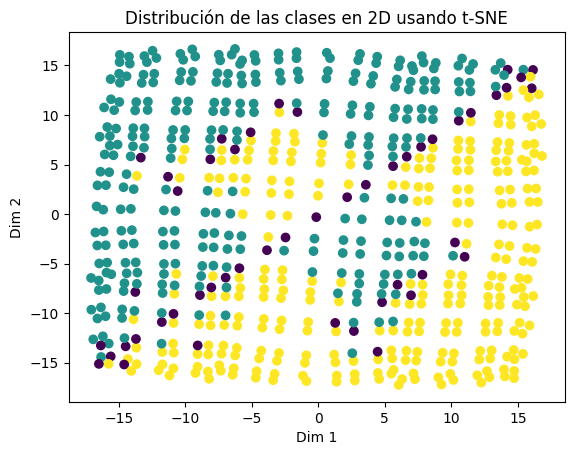

prec_score_train: [1. 1. 1.]
prec_score_test: [0.83333333 1.         1.        ]


In [4]:
df_balance = pd.read_csv('../Datos/Balance.csv')

display(df_balance.head())

X = np.array(df_balance.iloc[::,1::])
y = df_balance.iloc[::,0]

visualizar_en_2d(X,y)

y = label_binarizer.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)

alpha = 0.1
error = 1.0e-4
iteraciones = 5000

model = MLPClassifier(
    max_iter=iteraciones,
    hidden_layer_sizes=(16,8),
    alpha=alpha,
    solver="adam",
    activation="tanh",
    tol=error,
    verbose=False
).fit(
    X_train,
    y_train
)

y_pred = model.predict(X_train)
prec_score = precision_score(y_train, y_pred, average=None)

#print(f"y_pred_train: {y_pred}")
print(f"prec_score_train: {prec_score}")

y_pred = model.predict(X_test)
prec_score = precision_score(y_test, y_pred, average=None)

#print(f"y_pred_test: {y_pred}")
print(f"prec_score_test: {prec_score}")

### Ejercicio 5

El archivo **ZOO.csv** contiene información de 101 animales caracterizados por los siguientes atributos
1. Nombre del animal
2. Tiene Pelo
3. Plumas
4. Huevos
5. Leche
6. Vuela
7. Acuático
8. Depredador
9. Dentado
10. Vertebrado
11. Branquias
12. Venenoso
13. Aletas
14. Patas
15. Cola
16. Domestico
17. Tamaño gato
18. Clase

Salvo los atributos 1 y 18 que contienen texto y el 14 que contiene el número de patas del animal, el resto toma el valor 1 si el animal posee la característica y 0 si no. Hay 7 valores de clase posible (atributo 18): mamífero, ave, pez, invertebrado, insecto, reptil y anfibio.

Entrene un multiperceptrón que sea capaz de clasificar un animal en una de las 7 clases. Utilice el 70% de los ejemplos para entrenar y el 30% para realizar el testeo. Realice al menos 10 ejecuciones independientes de la configuración seleccionada para respaldar sus afirmaciones referidas a la performance del modelo.

Fuente de Datos: **Zoo Data Set** - https://archive.ics.uci.edu/ml/datasets/zoo

,animal,Tiene_Pelo,Tiene_Plumas,Nace_de_huevo,Toma_Leche,Vuela,Acuatico,Depredador,Dentado,Vertebrado,Respira,Venenoso,Tiene_Aletas,Cant_Patas,Tiene_Cola,Domestico,Tamano_Gato,Clase
0,oso_hormiguero,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,Mamifero
1,antilope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,Mamifero
2,robalo,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,Pez
3,oso,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,Mamifero
4,jabali,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,Mamifero


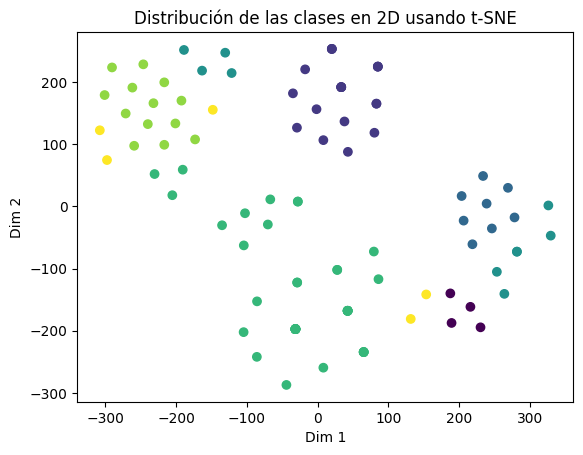

acc_score_train: 1.0
acc_score_test: 0.9032258064516129


In [5]:
df_zoo = pd.read_csv('../Datos/zoo.csv', encoding='latin1')
display(df_zoo.head())

X = np.array(df_zoo.iloc[::,1:17])
y = df_zoo.iloc[::,17]

visualizar_en_2d(X,y)

y = label_binarizer.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)

alpha = 0.1
error = 1.0e-4
iteraciones = 5000

model = MLPClassifier(
    max_iter=iteraciones,
    hidden_layer_sizes=(8),
    alpha=alpha,
    solver="adam",
    activation="tanh",
    verbose=False
).fit(
    X_train,
    y_train
)


y_pred = model.predict(X_train)
acc_score = accuracy_score(y_train, y_pred)

print(f"acc_score_train: {acc_score}")

y_pred = model.predict(X_test)
acc_score = accuracy_score(y_test, y_pred)

print(f"acc_score_test: {acc_score}")

### Ejercicio 6

Los archivos **Segment_Train.csv** y **Segment_Test.csv** contienen información referida a regiones de 3x3 pixeles pertenecientes a 7 imágenes distintas. Cada una corresponde a uno de los siguientes tipos de superficie: ladrillo, cielo, follaje, cemento, ventana, camino y pasto.

Cada región de 3x3 ha sido caracterizada por 19 atributos numéricos:

1. **region-centroid-col**: la columna del pixel central de la región.
2. **region-centroid-row**: la fila del pixel central de la región.
3. **region-pixel-count**: el número de pixeles de la región = 9.
4. **short-line-density-5**: el resultado de un algoritmo de extracción de líneas que cuenta la cantidad de líneas de bajo contraste que atraviesan la región.
5. **short-line-density-2**: ídem anterior para líneas de alto contraste.
6. **vedge-mean**: medida del contraste entre pixeles adyacentes. Este atributo contiene el valor promedio y el siguiente la desviación. Estas medidas sirven para detectar la presencia de un eje vertical.
7. **vegde-sd**: (ver 6)
8. **hedge-mean**: ídem 6 para eje horizontal. Contiene el valor medio y el siguiente la desviación.
9. **hedge-sd**: (ver 8).
10. **intensity-mean**: El promedio calculado sobre la región de la forma (R + G + B)/3
11. **rawred-mean**: el promedio sobre la región de los valores R.
12. **rawblue-mean**: el promedio sobre la región de los valores B.
13. **rawgreen-mean**: el promedio sobre la región de los valores G.
14. **exred-mean**: Medida de exceso de color rojo: (2R - (G + B))
15. **exblue-mean**: Medida de exceso de color azul: (2B - (G + R))
16. **exgreen-mean**: Medida de exceso de color verde: (2G - (R + B))
17. **value-mean**: Transformación no lineal 3D de RGB.
18. **saturatoin-mean**: (ver 17)
19. **hue-mean**: ver 17)
    
El atributo 20 corresponde al número de imagen de la cual fue extraída la región de 3x3. Sus valores son: 1 (ladrillo), 2 (cemento), 3(follaje), 4 (pasto), 5 (camino), 6 (cielo), 7 (ventana).
Entrene una red neuronal multiperceptrón para que dada una región de 3x3, representada a través de los 19 atributos indicados anteriormente, sea capaz de identificar a cuál de las 7 imágenes corresponde.
Utilice los ejemplos del archivo **Segment_Train.csv** para entrenar y los del archivo **Segment_Test.csv** para realizar el testeo.
Realice al menos 10 ejecuciones independientes de la configuración seleccionada para respaldar sus afirmaciones referidas a la performance del modelo.

Fuente: **Image Segmentation Data Set**: https://archive.ics.uci.edu/ml/datasets/Image+Segmentation

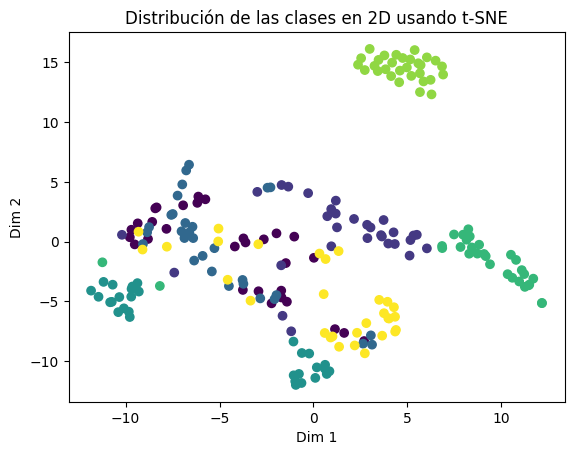

acc_score_train: 0.9095238095238095
acc_score_pred: 0.8666666666666667


In [6]:
df_segment_train = pd.read_csv('../Datos/segment_train.csv')
df_segment_test = pd.read_csv('../Datos/segment_test.csv')

X_train = np.array(df_segment_train.iloc[::,1::])
y_train = df_segment_train.iloc[::,0]

X_test = np.array(df_segment_test.iloc[::,1::])
y_test = df_segment_test.iloc[::,0]

visualizar_en_2d(X_train,y_train)

y_train = label_binarizer.fit_transform(y_train)
y_test = label_binarizer.fit_transform(y_test)

X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)


alpha = 0.1
error = 1.0e-4
iteraciones = 5000

model = MLPClassifier(
    max_iter=iteraciones,
    hidden_layer_sizes=(13),
    alpha=alpha,
    solver="adam",
    activation="tanh",
    verbose=False
).fit(
    X_train,
    y_train
)


y_pred = model.predict(X_train)
acc_score = accuracy_score(y_train, y_pred)

print(f"acc_score_train: {acc_score}")

y_pred = model.predict(X_test)
acc_score = accuracy_score(y_test, y_pred)

print(f"acc_score_pred: {acc_score}")

## Parte 2 - Multiperceptrón con Tensorflow/Keras
### Ejercicio 7
Re-implemente el modelo del ejercicio 4 (Balance.csv) utilizando un Multiperceptrón Tensorflow/Keras.

In [7]:
import numpy as np
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

balance_scale = fetch_ucirepo(id=12)
X = balance_scale.data.features          # DataFrame
y = balance_scale.data.targets           # Series con 'L','B','R'

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

num_features = X_train_s.shape[1]
num_classes  = len(le.classes_)  # 3

tf.random.set_seed(42)
np.random.seed(42)

model = keras.Sequential([
    layers.Input(shape=(num_features,)),
    layers.Dense(4, activation='tanh'),
    layers.Dense(2, activation='tanh'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.01),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

cb = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

history = model.fit(
    X_train_s, y_train_enc,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    callbacks=[cb],
    verbose=1
)

loss, acc = model.evaluate(X_test_s, y_test_enc, verbose=0)
print(f"Test accuracy: {acc:.2%}")

Epoch 1/300


C:\Users\gonza\Desktop\Facultad\Cuarto Año\DeepLearning\venv\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\gonza\Desktop\Facultad\Cuarto Año\DeepLearning\venv\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4725 - loss: 1.0078 - val_accuracy: 0.6400 - val_loss: 0.9253
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7500 - loss: 0.7849 - val_accuracy: 0.7600 - val_loss: 0.7429
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8375 - loss: 0.6246 - val_accuracy: 0.8600 - val_loss: 0.5793
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8700 - loss: 0.5020 - val_accuracy: 0.9000 - val_loss: 0.4565
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8775 - loss: 0.4178 - val_accuracy: 0.9100 - val_loss: 0.3785
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8975 - loss: 0.3648 - val_accuracy: 0.9100 - val_loss: 0.3275
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8975 - loss: 0.3305 - val_accuracy: 0.9100 - val_loss: 0.2951
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8950 - loss: 0.3074 - val_accuracy: 0.9100 - val_loss: 0

### Ejercicio 8

Utilizando el archivo **Iris.csv** que contiene información referida a la longitud y al ancho de sépalos y pétalos de tres especies de flores: iris setosa, iris versicolor e iris virginica.

1. Entrenar una multiperceptrón que aprenda a clasificar las 3 clases de flores.
2. Utilice Python para calcular la matriz de confusión y calcule de forma manual las métricas de **precision**, **recall**, **accuracy** y **f1-score**. Luego utilice la función **classification_report** de SciKit-Learn para comparar los resultados.

### 1.

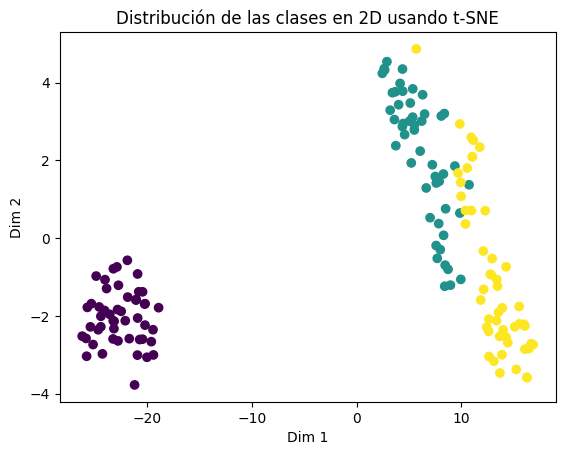

Epoch 1/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.2708 - loss: 1.5080 - val_accuracy: 0.2500 - val_loss: 1.3144
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2708 - loss: 1.3869 - val_accuracy: 0.3333 - val_loss: 1.2227
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2917 - loss: 1.2757 - val_accuracy: 0.3750 - val_loss: 1.1382
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4167 - loss: 1.1738 - val_accuracy: 0.4167 - val_loss: 1.0616
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4479 - loss: 1.0817 - val_accuracy: 0.3750 - val_loss: 0.9935
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4688 - loss: 0.9999 - val_accuracy: 0.4583 - val_loss: 0.9341
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5000 - loss: 0.9284 - val_accuracy: 0.5000 - val_loss: 0.8829
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.5625 - loss: 0.8667 - val_accuracy: 0.5000 - val_loss

In [12]:
df_iris = pd.read_csv('../Datos/Iris.csv')

X = np.array(df_iris.iloc[::,0:4])
y = df_iris.iloc[::,4]

visualizar_en_2d(X,y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

model = keras.Sequential([
    layers.Input(shape=[4]),
    layers.Dense(3, activation='tanh'),
    layers.Dense(3, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.01),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

cb = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

history = model.fit(
    X_train_s, y_train_enc,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    callbacks=[cb],
    verbose=1
)

loss, acc = model.evaluate(X_test_s, y_test_enc, verbose=0)
print(f"Test accuracy: {acc:.2%}")

### 2.

In [14]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

labels = np.arange(len(le.classes_))
cm = confusion_matrix(y_test_enc, y_pred, labels=labels)
print("Matriz de confusión (filas = y_true, columnas = y_pred):\n", cm, "\n")

n_classes = len(labels)
tp = np.diag(cm).astype(float)
fp = cm.sum(axis=0) - tp
fn = cm.sum(axis=1) - tp
tn = cm.sum() - (tp + fp + fn)
support = cm.sum(axis=1).astype(int)  

precision_per_class = np.where(tp + fp > 0, tp / (tp + fp), 0.0)
recall_per_class    = np.where(tp + fn > 0, tp / (tp + fn), 0.0)
f1_per_class = np.where(
    (precision_per_class + recall_per_class) > 0,
    2 * precision_per_class * recall_per_class / (precision_per_class + recall_per_class),
    0.0
)

accuracy = tp.sum() / cm.sum()

macro_precision = precision_per_class.mean()
macro_recall    = recall_per_class.mean()
macro_f1        = f1_per_class.mean()

weighted_precision = np.average(precision_per_class, weights=support)
weighted_recall    = np.average(recall_per_class, weights=support)
weighted_f1        = np.average(f1_per_class, weights=support)

# Micro (en multiclass single-label, micro P=R=F1)
tp_micro = tp.sum()
fp_micro = fp.sum()
fn_micro = fn.sum()
precision_micro = tp_micro / (tp_micro + fp_micro) if (tp_micro + fp_micro) > 0 else 0.0
recall_micro    = tp_micro / (tp_micro + fn_micro) if (tp_micro + fn_micro) > 0 else 0.0
f1_micro = (
    2 * precision_micro * recall_micro / (precision_micro + recall_micro)
    if (precision_micro + recall_micro) > 0 else 0.0
)

print("=== Métricas calculadas a mano ===")
for i, cls in enumerate(le.classes_):
    print(f"Clase '{cls}':  support={support[i]}, "
          f"precision={precision_per_class[i]:.4f}, "
          f"recall={recall_per_class[i]:.4f}, "
          f"f1={f1_per_class[i]:.4f}")

print(f"\nAccuracy global: {accuracy:.4f}")

print("\nMacro avg: "
      f"precision={macro_precision:.4f}, recall={macro_recall:.4f}, f1={macro_f1:.4f}")

print("Weighted avg: "
      f"precision={weighted_precision:.4f}, recall={weighted_recall:.4f}, f1={weighted_f1:.4f}")

print("Micro avg: "
      f"precision={precision_micro:.4f}, recall={recall_micro:.4f}, f1={f1_micro:.4f}\n")

print("=== classification_report (scikit-learn) ===")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_, digits=4))

Matriz de confusión (filas = y_true, columnas = y_pred):
 [[ 0 10  0]
 [ 0  0 10]
 [ 0  0 10]] 

=== Métricas calculadas a mano ===
Clase 'Iris-setosa':  support=10, precision=0.0000, recall=0.0000, f1=0.0000
Clase 'Iris-versicolor':  support=10, precision=0.0000, recall=0.0000, f1=0.0000
Clase 'Iris-virginica':  support=10, precision=0.5000, recall=1.0000, f1=0.6667

Accuracy global: 0.3333

Macro avg: precision=0.1667, recall=0.3333, f1=0.2222
Weighted avg: precision=0.1667, recall=0.3333, f1=0.2222
Micro avg: precision=0.3333, recall=0.3333, f1=0.3333

=== classification_report (scikit-learn) ===
                 precision    recall  f1-score   support

    Iris-setosa     0.0000    0.0000    0.0000        10
Iris-versicolor     0.0000    0.0000    0.0000        10
 Iris-virginica     0.5000    1.0000    0.6667        10

       accuracy                         0.3333        30
      macro avg     0.1667    0.3333    0.2222        30
   weighted avg     0.1667    0.3333    0.2222   

C:\Users\gonza\AppData\Local\Temp\ipykernel_20892\4276028700.py:18: RuntimeWarning: invalid value encountered in divide
  precision_per_class = np.where(tp + fp > 0, tp / (tp + fp), 0.0)
C:\Users\gonza\AppData\Local\Temp\ipykernel_20892\4276028700.py:22: RuntimeWarning: invalid value encountered in divide
  2 * precision_per_class * recall_per_class / (precision_per_class + recall_per_class),
C:\Users\gonza\Desktop\Facultad\Cuarto Año\DeepLearning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\gonza\Desktop\Facultad\Cuarto Año\DeepLearning\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

### Ejercicio 9

Utilizando los ejemplos del archivo **AUTOS.csv** genere un modelo utilizando un multiperceptrón para predecir el precio del auto (atributo **price**) y la cantidad de millas por galón en ruta (**MPG-highway**) en función del resto de los atributos. Recuerde completar los valores faltantes, utilizar normalización y dividir el dataset en entrenamiento y validación (80/20).

Realice 20 ejecuciones independientes de cada configuración seleccionada calculando las épocas promedio y al error cuadrático medio (ECM). Analice los resultados y respalde las afirmaciones referidas a los resultados obtenidos. Utilice un máximo de 1000 épocas con lotes de 50 e implemente una parada temprana con paciencia de 15.

In [17]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow import random as tf_random
from tensorflow.keras import layers

# =========================
# CONFIG
# =========================
CSV_PATH = "../Datos/autos.csv"           # o "autos.csv" si lo tenés en el cwd
TARGET_COLS = ['price', 'highway-mpg']
TEST_SIZE = 0.20
VAL_SPLIT = 0.20
BATCH_SIZE = 50
MAX_EPOCHS = 1000
PATIENCE = 15
N_RUNS = 20

# Para compararte con la cátedra:
# - True: solo columnas NUMÉRICAS (como su ejemplo)
# - False: incluye categóricas con one-hot (más completo, pero no comparable 1:1)
USE_ONLY_NUMERIC = True

# Modelos a probar (optimizadores x activaciones)
ACTIVATIONS = ['tanh', 'sigmoid', 'relu', 'leaky_relu']
OPTIM_NAMES = ['sgd', 'rmsprop', 'adam']


# =========================
# DATA: carga + limpieza
# =========================
df = pd.read_csv(CSV_PATH, na_values=['?', '??', 'NA', '', 'null'])

# Imputación simple: numérico -> media; categórico -> moda
for c in df.columns:
    if df[c].dtype == 'object':
        df[c] = df[c].fillna(df[c].mode().iloc[0])
    else:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(df[c].mean())

# Targets y features
y = df[TARGET_COLS].astype(float)
X = df.drop(columns=TARGET_COLS)

if USE_ONLY_NUMERIC:
    X = X.select_dtypes(include='number')
else:
    # one-hot SOLO categóricas
    cat_cols = X.select_dtypes(include='object').columns
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Split
X_tr, X_te, Y_tr, Y_te = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42, shuffle=True
)

# Escalado features (todas numéricas en este camino) y targets (para entrenar y medir ECM_z)
xscaler, yscaler = StandardScaler(), StandardScaler()
X_tr = pd.DataFrame(xscaler.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
X_te = pd.DataFrame(xscaler.transform(X_te), columns=X_te.columns, index=X_te.index)

Y_tr_s = yscaler.fit_transform(Y_tr.values)  # (n,2)
Y_te_s = yscaler.transform(Y_te.values)


# =========================
# Utils: optimizador y modelo
# =========================
def make_optimizer(name, lr=1e-3):
    name = name.lower()
    if name == 'sgd':
        return keras.optimizers.SGD(learning_rate=lr, clipnorm=1.0, momentum=0.0, nesterov=False)
    if name == 'rmsprop':
        return keras.optimizers.RMSprop(learning_rate=lr, clipnorm=1.0)
    if name == 'adam':
        return keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0)
    raise ValueError(name)

def build_model(input_dim, act):
    model = keras.Sequential([layers.Input(shape=(input_dim,))])
    # arquitectura simple (como cátedra), 2 capas chicas
    if act == 'leaky_relu':
        model.add(layers.Dense(6))
        model.add(layers.LeakyReLU(negative_slope=0.2))
        model.add(layers.Dense(3))
        model.add(layers.LeakyReLU(negative_slope=0.2))
    else:
        model.add(layers.Dense(6, activation=act))
        model.add(layers.Dense(3, activation=act))
    model.add(layers.Dense(2, activation='linear'))  # 2 salidas
    return model


# =========================
# Experimentos
# =========================
results = []
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=PATIENCE, restore_best_weights=True, mode='min'
)

for opt_name in OPTIM_NAMES:
    for act in ACTIVATIONS:
        epochs_list = []
        mse_z_list = []       # ECM en espacio estandarizado (comparable con cátedra)
        mse_orig_list = []    # ECM desescalado (interpretativo)

        for run in range(N_RUNS):
            seed = 1000 + 97 * run
            np.random.seed(seed)
            tf_random.set_seed(seed)

            model = build_model(X_tr.shape[1], act)
            model.compile(optimizer=make_optimizer(opt_name, lr=1e-3),
                          loss='mse', metrics=['mae'])

            hist = model.fit(
                X_tr, Y_tr_s,
                validation_split=VAL_SPLIT,
                epochs=MAX_EPOCHS,
                batch_size=BATCH_SIZE,
                verbose=0,
                callbacks=[early_stop]
            )
            epochs_list.append(len(hist.history['loss']))

            # ECM_z (validación): tomamos el mínimo alcanzado (consistente con early stopping)
            mse_z_best = float(np.min(hist.history['val_loss']))
            mse_z_list.append(mse_z_best)

            # ECM_original: predigo en test, desescalo y calculo ECM global promedio entre targets
            Y_pred_s = model.predict(X_te, verbose=0)
            Y_pred = yscaler.inverse_transform(Y_pred_s)
            mse_orig = float(np.mean((Y_pred - Y_te.values) ** 2))
            mse_orig_list.append(mse_orig)

        results.append({
            'Optimizador': opt_name.upper(),
            'Función de activación': {'tanh': 'tanh', 'sigmoid': 'sigmoid',
                                      'relu': 'ReLU', 'leaky_relu': 'LeakyReLU'}[act],
            'Épocas promedio': np.mean(epochs_list),
            # Lo que pide la cátedra (ECM en validación sobre z-scores):
            'ECM Promedio': np.mean(mse_z_list),
            # Extra útil (no entra en la tabla oficial, pero lo guardamos):
            'ECM_original Promedio': np.mean(mse_orig_list),
        })

# Orden de salida como en el enunciado
order_opt = ['SGD', 'RMSPROP', 'ADAM']
order_act = ['tanh', 'sigmoid', 'ReLU', 'LeakyReLU']
res_df = pd.DataFrame(results)
res_df['__o1'] = res_df['Optimizador'].map({k: i for i, k in enumerate(order_opt)})
res_df['__o2'] = res_df['Función de activación'].map({k: i for i, k in enumerate(order_act)})
res_df = res_df.sort_values(['__o1', '__o2']).drop(columns=['__o1', '__o2'])

# Impresión de la tabla EXACTA que te piden (épocas + ECM en z-score)
print("\n=== Tabla para entregar (ECM en z-score, validación) ===")
print(res_df[['Optimizador', 'Función de activación',
              'Épocas promedio', 'ECM Promedio']].to_string(
    index=False,
    float_format=lambda x: f"{x:.2f}" if x >= 10 else f"{x:.5f}"
))

# Guardamos CSV con todo (incluye ECM_original por si querés anexar)
out_csv = "resultados_autos_mlp_resumen.csv"
res_df.to_csv(out_csv, index=False)
print(f"\nArchivo guardado: {out_csv}")


=== Tabla para entregar (ECM en z-score, validación) ===
Optimizador Función de activación  Épocas promedio  ECM Promedio
        SGD                  tanh            64.25       1.57566
        SGD               sigmoid            15.00       1.66088
        SGD                  ReLU            15.00       1.78562
        SGD             LeakyReLU            15.00       1.67232
    RMSPROP                  tanh            15.00       1.12267
    RMSPROP               sigmoid            15.00       1.50379
    RMSPROP                  ReLU            15.00       1.34479
    RMSPROP             LeakyReLU            15.00       1.38372
       ADAM                  tanh            15.00       1.32142
       ADAM               sigmoid            15.00       1.44507
       ADAM                  ReLU            15.00       1.43011
       ADAM             LeakyReLU            15.00       1.18104

Archivo guardado: resultados_autos_mlp_resumen.csv
